# **Job Matching Analysis (EDA)**
**Objectives** : The objective of this notebook is to prepare and analyze candidate and job posting datasets for an AI-based job matching system.

**Methodolgy:** Hybrid Job Matching Training Method

The hybrid job matching model combines rule-based filtering with semantic similarity to rank job postings for each candidate. Instead of relying on a single feature, the model integrates multiple matching signals to improve recommendation quality.

**Importing Libraries**






In [42]:
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [43]:
candidate_path = kagglehub.dataset_download("ckshetty/candidate-job-role-dataset")
job_path = kagglehub.dataset_download("arshkon/linkedin-job-postings")
print("Dataset downloaded to:", candidate_path,job_path)
print(candidate_path)
print(os.listdir(candidate_path))
print(os.listdir(job_path))

Using Colab cache for faster access to the 'candidate-job-role-dataset' dataset.
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Dataset downloaded to: /kaggle/input/candidate-job-role-dataset /kaggle/input/linkedin-job-postings
/kaggle/input/candidate-job-role-dataset
['candidate_job_role_dataset.csv']
['companies', 'mappings', 'jobs', 'postings.csv']


**Loading the Datasets**

**1.Candidate Job Role Dataset** : Provides structured candidate information such as skills, preferred job role, education, and experience, which is used to build candidate profiles.

**2.LinkedIn Job Postings Dataset** : Contains real-world job postings with job titles, descriptions, required skills, locations, and employment details, making the job matching realistic.

In [44]:
import pandas as pd
import os
candidate_df = pd.read_csv(os.path.join(candidate_path,"candidate_job_role_dataset.csv"))
candidate_df.head()

,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


## Feature Description

| Feature | Data Type | Description |
|---------|-----------|-------------|
| **candidate_id** | Integer | Unique identifier assigned to each candidate. Used as a primary key and does not contribute to model learning. |
| **skills** | Text (Categorical/String) | Contains the candidate's technical and soft skills, separated by commas (e.g., Python, SQL, TensorFlow, Teamwork). This feature can be processed using text encoding or vectorization techniques. |
| **qualification** | Categorical | Represents the candidate's highest educational qualification (e.g., Bachelor's in Computer Science, Master's in Data Science). |
| **experience_level** | Categorical | Indicates the candidate's level of work experience, such as **Entry**, **Mid**, or **Senior**. |
| **job_role** | Categorical (Target Variable) | Specifies the candidate's job role (e.g., Data Scientist, Frontend Developer, Backend Developer, Designer). This is the target variable for the classification model. |


In [45]:
job_df = pd.read_csv(os.path.join(job_path,"postings.csv"))
job_df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## Feature Description

| Feature | Data Type | Description |
|---------|-----------|-------------|
| **job_id** | Integer | Unique identifier assigned to each job posting. Serves as the primary key and is not used for predictive modeling. |
| **company_name** | Categorical (String) | Name of the company offering the job position. |
| **title** | Text (String) | Title or designation of the job (e.g., Sales Manager, Software Engineer). |
| **description** | Text (String) | Detailed description of the job responsibilities, requirements, qualifications, and other relevant information. |
| **location** | Categorical (String) | Geographic location where the job is offered (city, state, or country). |
| **formatted_work_type** | Categorical | Human-readable work arrangement, such as **Full-time**, **Part-time**, **Contract**, or **Internship**. |
| **application_type** | Categorical | Specifies how candidates apply for the job (e.g., **OffsiteApply**, **SimpleApply**). |
| **formatted_experience_level** | Categorical | Human-readable experience level required for the job, such as **Entry level**, **Associate**, **Mid-Senior level**, or **Executive**. |
| **skills_desc** | Text (String) | Text describing the required technical and soft skills for the job. This field may contain missing values. |
| **listed_time** | Integer (Timestamp) | Unix timestamp indicating when the job posting was listed. Can be converted into a date-time format for temporal analysis. |
| **work_type** | Categorical | Standardized work type, such as **FULL_TIME**, **PART_TIME**, **CONTRACT**, etc. |
| **compensation_type** | Categorical | Type of compensation offered, such as **BASE_SALARY**. |
| **normalized_salary** | Numeric (Float) | Standardized salary value converted into a common scale to facilitate salary comparison across different pay periods. |

## 1. Dataset Suitability Justification

### 1.1 Geographic Representativeness

The **LinkedIn Job Postings** dataset (Kaggle: `arshkon/linkedin-job-postings`) is scraped from LinkedIn's public postings and is **not geographically balanced by design** — it reflects wherever LinkedIn's scraper found active postings, which skews toward the United States and other English-speaking markets. This matters directly for our use case, because a job-matching module aimed at Indian candidates needs enough India-based postings to learn realistic title/skill/salary patterns for that market. The cell below quantifies this rather than assuming it.

In [46]:
# How many postings are explicitly tied to India, and what does the location field look like overall?
india_mask = job_df['location'].astype(str).str.contains('India', case=False, na=False)
india_count = india_mask.sum()
total_count = len(job_df)

print(f"Postings mentioning 'India': {india_count} out of {total_count} ({india_count/total_count:.2%})")
print()
print("Top 15 locations overall:")
print(job_df['location'].value_counts().head(15))

Postings mentioning 'India': 742 out of 123849 (0.60%)

Top 15 locations overall:
location
United States                      8125
New York, NY                       2756
Chicago, IL                        1834
Houston, TX                        1762
Dallas, TX                         1383
Atlanta, GA                        1363
Boston, MA                         1176
Austin, TX                         1083
Charlotte, NC                      1075
Phoenix, AZ                        1059
Washington, DC                      985
Los Angeles, CA                     972
San Francisco, CA                   884
New York City Metropolitan Area     837
Seattle, WA                         818
Name: count, dtype: int64


### **1.1 Geographic Representativeness**

The LinkedIn Job Postings dataset (Kaggle: *arshkon/linkedin-job-postings*) is **not geographically balanced**, as it is collected from publicly available LinkedIn postings rather than through a stratified sampling process. As a result, the dataset is heavily dominated by **United States** job postings.

Our analysis confirms this imbalance:

* Total job postings: **123,849**
* Postings mentioning **India**: **742 (0.60%)**
* The top locations are overwhelmingly U.S.-based, with **United States (8,125)**, **New York, NY (2,756)**, **Chicago, IL (1,834)**, **Houston, TX (1,762)**, and **Dallas, TX (1,383)** among the most frequent.

This indicates that the dataset primarily represents the **U.S. labor market**, while Indian job postings form only a very small proportion of the data. Consequently, the dataset is **not representative of the Indian job market**, and any salary trends, hiring patterns, or qualification requirements learned from it may not generalize well to India.

For this project, the dataset is therefore used **to analyze general relationships between job roles, skills, qualifications, and experience**, rather than to draw conclusions about the Indian employment market. A production-grade job-matching system targeting Indian candidates would require a dataset with substantially greater coverage of India-specific job postings.


> For this project, the dataset is used **to evaluate the performance of the job ranking algorithm by analyzing the relationships between job roles, skills, qualifications, and experience**. Although the dataset is predominantly composed of U.S.-based job postings, it provides a diverse set of occupations and skill requirements that are suitable for assessing whether the ranking algorithm correctly prioritizes relevant jobs based on candidate profiles. Since the primary objective is **algorithm evaluation rather than modeling the Indian job market**, the geographic imbalance does not significantly affect the validity of the ranking experiments. However, for deployment as a production-grade job recommendation system for Indian candidates, a dataset with substantially greater coverage of India-specific job postings would be necessary.

**Key takeaway:** The geographic imbalance is a **known limitation** of the dataset and is explicitly acknowledged to ensure that the findings are interpreted within the appropriate context.

# **1.2 Recency**

The dataset is a **static snapshot collected in 2023–2024**, not a live feed. `listed_time` lets us confirm the actual date range covered.

In [47]:
# Confirm the actual time window the dataset covers
job_df['listed_datetime'] = pd.to_datetime(job_df['listed_time'], unit='ms', errors='coerce')
print("Earliest posting:", job_df['listed_datetime'].min())
print("Latest posting:  ", job_df['listed_datetime'].max())
print("Span (days):     ", (job_df['listed_datetime'].max() - job_df['listed_datetime'].min()).days)

Earliest posting: 2024-03-24 21:50:14
Latest posting:   2024-04-20 00:26:56
Span (days):      26


# 1.2 Data Recency

The dataset contains job postings published between 24 March 2024 and 20 April 2024, spanning 26 days. This relatively short collection period means that the postings represent a consistent snapshot of the job market, reducing the influence of long-term changes in hiring trends, required skills, and qualification requirements.

For this project, the primary objective is to evaluate the job ranking algorithm, rather than to analyze long-term labor market trends. A concentrated time window is therefore appropriate because it ensures that the jobs being ranked are contemporaneous and comparable, allowing the algorithm to be evaluated under realistic hiring conditions. Although the dataset does not capture seasonal or long-term changes in recruitment patterns, its recency provides a representative snapshot that is sufficient for assessing the effectiveness of the proposed ranking approach.

### 1.3 Industry Coverage

 The top titles span **Sales Manager, Customer Service Representative, Project Manager**, alongside software/technical roles — i.e., the dataset is **multi-industry, not IT-exclusive**. This is a genuine strength: it gives the matcher exposure to non-tech vocabulary and prevents the model from overfitting to a software-only worldview. The trade-off (addressed below) is that the **candidate-side** dataset is IT/software-skewed, creating an industry-coverage *mismatch* between the two sources.

### 1.4 Alignment with ESCO Occupations

Neither `job_role` (candidate side, 22 controlled categories) nor `title` (job side, 72,521 free-text values) is currently mapped to the **ESCO** (European Skills, Competences, Qualifications and Occupations) taxonomy. This is worth stating plainly rather than assuming compatibility:

In [80]:
import pandas as pd
import re

# 1. Load ESCO reference (already uploaded)
esco = pd.read_csv("esco_reference.csv")

# 2. Build a lookup: every ESCO title + alt title (lowercased) -> canonical occupation_title
lookup = {}
token_index = {}  # lowercased title -> set of word tokens (for fuzzy matching)

for _, row in esco.iterrows():
    titles = [row['occupation_title']]
    if pd.notna(row['alt_occupation_title']):
        titles += [t.strip() for t in row['alt_occupation_title'].split(';')]
    for t in titles:
        tl = t.lower().strip()
        lookup.setdefault(tl, row['occupation_title'])
        token_index[tl] = set(re.sub(r'[^a-z0-9 ]', ' ', tl).split())

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a or b) else 0

def match_to_esco(title, cutoff=0.5):
    """Return (matched ESCO occupation, score, match_type) for a job title/role string."""
    t_raw = title.lower().strip()
    if t_raw in lookup:
        return lookup[t_raw], 1.0, 'exact'

    t_tokens = set(re.sub(r'[^a-z0-9 ]', ' ', t_raw).split())
    best_title, best_score = None, 0.0
    for tl, toks in token_index.items():
        score = jaccard(t_tokens, toks)
        if score > best_score:
            best_score, best_title = score, tl

    if best_score >= cutoff:
        return lookup[best_title], round(best_score, 3), 'fuzzy'
    return None, round(best_score, 3), 'no_match'

# 3. Check candidate job_role values
results = []
for role in candidate_df['job_role'].unique():
    esco_title, score, kind = match_to_esco(role)
    results.append({'source_title': role, 'esco_match': esco_title, 'score': score, 'match_type': kind})

candidate_match_df = pd.DataFrame(results)
print(candidate_match_df)

match_rate = (candidate_match_df['match_type'] != 'no_match').mean()
print(f"\nCandidate job_role ESCO match rate: {match_rate:.1%}")

# 4. Same check for job postings (use top N titles — free text has huge cardinality)
top_titles = job_df['title'].value_counts().head(50).index
job_results = [{'source_title': t, **dict(zip(
    ['esco_match','score','match_type'], match_to_esco(t)))} for t in top_titles]

job_match_df = pd.DataFrame(job_results)
print(job_match_df)
print(f"\nTop-50 job title ESCO match rate: {(job_match_df['match_type'] != 'no_match').mean():.1%}")

                      source_title                          esco_match  score  \
0                   Data Scientist                      data scientist  1.000   
1               Frontend Developer                                None  0.333   
2                Backend Developer                                None  0.333   
3                         Designer                        art director  1.000   
4      Full Stack Python Developer                                None  0.286   
5                          Finance                   financial auditor  0.500   
6                   Game Developer            gambling games developer  0.667   
7                  DevOps Engineer               cloud DevOps engineer  1.000   
8        Full Stack Java Developer                                None  0.286   
9             Blockchain Developer                blockchain developer  1.000   
10                       Marketing                 commercial director  0.500   
11                          

### **1.4 Alignment with ESCO Occupations**

* **68.2% of the candidate job roles** were successfully matched to ESCO occupations, demonstrating a **good level of compatibility** between the project's job-role taxonomy and the ESCO occupational classification.
* **Exact matches** were obtained for common technical roles such as **Data Scientist, DevOps Engineer, Blockchain Developer, Data Analyst, Web Developer,** and **Cybersecurity Engineer**, indicating strong alignment with standardized ESCO occupations.
* Several roles, including **Software Project Manager, Mobile Developer, Video Game Designer, Finance,** and **HR**, achieved **fuzzy matches**, reflecting semantic similarity despite differences in naming conventions.
* Emerging or organization-specific roles such as **AIML, Full Stack Python Developer, Full Stack Java Developer,** and **Backend Developer** did not have direct ESCO equivalents, highlighting the evolving nature of modern IT job titles.
* The **Top-50 most frequent job titles** achieved an **ESCO match rate of 92%**, indicating that the vast majority of commonly used industry job titles correspond well to standardized ESCO occupations.
* The improved match rate is attributed to the use of **alternative ESCO occupation titles** and **Jaccard-based fuzzy matching**, which successfully captures synonymous and closely related job titles that would otherwise remain unmatched.
* Overall, the high match rate confirms that the dataset is **well aligned with the ESCO taxonomy**, supporting the use of ESCO as a standardized occupational framework for evaluating and validating the proposed job ranking algorithm.

### 1.5 Summary Table

| Criterion | Verdict | Basis |
|---|---|---|
| Geographic representativeness | Global-majority, India-minority | `location` field analysis (1.1) |
| Recency | Static 2023–2024 snapshot, not live | `listed_time` range (1.2) |
| Industry coverage | Broad / multi-industry on job side, IT-skewed on candidate side | Section 3 insights + 1.3 |
| ESCO alignment | Not yet mapped | 1.4 |

The dataset pair is judged **sufficient to prototype** the hybrid matcher's mechanics (rule filtering + semantic similarity), but **not yet sufficient to claim India-representativeness or ESCO-standard occupation coverage** — both are pre-conditions to fix before any India-facing or ontology-based deployment.

## **2. Dataset Limitations**

Stated explicitly, rather than implied by the descriptive statistics above:

**Candidate Job Role Dataset**
- Only **1,000 rows** — small relative to the 123,849 job postings, and small for training a robust classifier once split into train/validation/test.
- Only **98 unique skill combinations** across 1,000 candidates (from Section on Skills, cell 73) — a ratio suggesting the skill strings are **templated/synthetically generated** rather than organically written resumes, so the dataset may under-represent the noisiness (typos, inconsistent phrasing, overlapping synonyms) of real resumes.
- **22 job roles, all software/IT-oriented** (e.g., Mobile Developer, DevOps Engineer, Blockchain Developer) — there is **no candidate-side coverage** of the non-tech roles (Sales Manager, Customer Service Representative) that dominate the job-posting side. This is a structural mismatch, not just an imbalance.
- A data-entry artifact (an extra `"Entry, "` category alongside `"Entry"`) confirms the dataset has not been fully cleaned upstream.

**LinkedIn Job Postings Dataset**
- **Single-platform bias**: sourced only from LinkedIn, excluding postings that only appear on other boards, company career pages, or informal/offline channels — so it is not representative of "the job market," only of "the LinkedIn-visible job market."
- **~29,000 missing `formatted_experience_level` rows** and a majority-missing `skills_desc` field (from the Missing Value Analysis above) — both are important matching signals, so their absence has to be handled (imputation, exclusion, or a fallback rule) rather than ignored.
- **Salary is missing for the majority of postings.** This is not missing-at-random: postings with disclosed salary skew toward regions/companies with pay-transparency norms (largely U.S.), so any salary-based feature inherits that same geographic bias flagged in Section 1.1.
- **Extreme title fragmentation**: 72,521 unique titles across 123,849 postings (≈1.7 postings per title) means `title` is far too sparse to use as a classification target directly — it needs normalization/clustering first.
- **Exact-duplicate checks (`duplicated()`) will not catch near-duplicates** — e.g., the same company posting a near-identical "Software Engineer" opening in five different cities is not flagged as a duplicate row even though it may inflate the effective weight of that company/title in training.

These limitations mean the current dataset pair is a reasonable **prototyping foundation**, but several gaps (candidate-side industry coverage, salary-field bias, title fragmentation) need explicit preprocessing decisions before the matching model is trusted end-to-end.

## 3. From Observation to Preprocessing Decision

The EDA above repeatedly notes that a feature is "imbalanced" or "skewed" without stating what follows from it. This section computes the actual imbalance ratios and pairs each one with a concrete decision.

In [49]:
def imbalance_ratio(series, top_n=None):
    counts = series.value_counts()
    if top_n:
        counts = counts.head(top_n)
    return counts.max() / counts.min(), counts

for name, series in [
    ("candidate_df['job_role']", candidate_df['job_role']),
    ("candidate_df['qualification']", candidate_df['qualification']),
    ("job_df['formatted_experience_level']", job_df['formatted_experience_level']),
    ("job_df['formatted_work_type']", job_df['formatted_work_type']),
]:
    ratio, counts = imbalance_ratio(series)
    print(f"{name}: max/min imbalance ratio = {ratio:.1f}:1  (max={counts.max()}, min={counts.min()})")

# title is a special case: too many classes to summarize with a single ratio meaningfully
title_counts = job_df['title'].value_counts()
print(f"\njob_df['title']: {title_counts.shape[0]} unique values, "
      f"top class = {title_counts.iloc[0]}, median class size = {title_counts.median():.0f}, "
      f"{ (title_counts == 1).sum() } titles appear exactly once")

candidate_df['job_role']: max/min imbalance ratio = 75.0:1  (max=75, min=1)
candidate_df['qualification']: max/min imbalance ratio = 349.0:1  (max=349, min=1)
job_df['formatted_experience_level']: max/min imbalance ratio = 34.0:1  (max=41489, min=1222)
job_df['formatted_work_type']: max/min imbalance ratio = 202.9:1  (max=98814, min=487)

job_df['title']: 72521 unique values, top class = 673, median class size = 1, 60922 titles appear exactly once


**Decisions, mapped to each measured imbalance:**

| Feature | Role in the model | Measured imbalance | Preprocessing decision |
|---|---|---|---|
| `candidate_df['job_role']` | Classification **target** for candidate profiling | Moderate (see output above) | **Stratified train/validation/test split** to preserve class proportions, plus a **class-weighted loss** (inverse-frequency weights) at training time. Oversampling is deliberately avoided here — with only 1,000 rows and 98 unique skill strings, duplicating minority-class rows would mean training on literal repeats of the same skill string, risking memorization rather than generalization. |
| `candidate_df['qualification']` | Auxiliary/explanatory feature, not the target | High (specialized degrees are rare) | No resampling needed — it's an **input feature**, not a target. Rare categories will instead be **grouped into broader buckets** (e.g., all Master's-level degrees together) at encoding time so the model doesn't need to learn dozens of near-singleton categories. |
| `job_df['formatted_experience_level']` | Rule-based **filter** in the hybrid matcher, and a secondary evaluation slice | High (Mid-Senior/Entry dominate) | Since this is used for **filtering, not as a trained target**, the imbalance mainly threatens *evaluation*, not training. Decision: report **macro-averaged / per-class metrics** (not just overall accuracy) when validating match quality, so rare slices (Internship, Executive) aren't invisible in aggregate scores. |
| `job_df['formatted_work_type']` | Rule-based filter | Very high (Full-time dominates) | Same as above — **balanced evaluation**, not resampling, since it's a filter field rather than a learned label. |
| `job_df['title']` | Would-be classification target if used directly | Extreme — long-tail, most titles appear once | Too fragmented to weight or oversample meaningfully as-is. Decision: **normalize/cluster titles into a smaller controlled taxonomy first** (e.g., map toward the 22 `job_role` categories or an ESCO occupation list — see Section 1.4), and only decide on weighting/oversampling *after* that taxonomy exists. Attempting to class-weight 72,521 raw title values would be both computationally wasteful and statistically meaningless for singleton classes. |

The general rule applied here: **imbalance in a feature used as a trained target** gets stratified sampling + weighted loss; **imbalance in a feature used as a rule-based filter** gets balanced evaluation metrics instead, since there's nothing being "trained" on it to rebalance.

### **EDA for Candidates Datasets**


**1. Dataset Summary Statistics for Candidates**

In [50]:
# Shape
print("Dataset Shape:", candidate_df.shape)

Dataset Shape: (1000, 5)


In [51]:
# Summary statistics
candidate_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
candidate_id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
skills,1000,98,"PHP, Laravel, MySQL, JavaScript",25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qualification,1000,17,Bachelor's in Computer Science,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,1000,4,Mid,401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_role,1000,22,Mobile Developer,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Experience Level:** Candidates are categorized into 4 experience levels (e.g.,
Entry, Junior, Mid, Senior). The Mid-level category is the largest, containing 401 candidates, indicating that the dataset mainly represents professionals with moderate industry experience.

**Job Role:** The dataset includes 22 unique job roles, reflecting a variety of software and IT professions. The most common role is Mobile Developer, with 75 candidates, followed by other software development positions.

In [52]:
# Data types
candidate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      1000 non-null   int64 
 1   skills            1000 non-null   object
 2   qualification     1000 non-null   object
 3   experience_level  1000 non-null   object
 4   job_role          1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


In [53]:
candidate_df.columns

Index(['candidate_id', 'skills', 'qualification', 'experience_level',
       'job_role'],
      dtype='object')


### Dataset Overview

| Property | Value |
|----------|-------|
| **Total Features** | 5 |
| **Total Sample** | 1000 |
| **Numerical Features** | 1 (candidate_id) |
| **Categorical Features** | 4 (skills, qualification, experience_level, job_role) |
| **Target Variable** | job_role |
| **Primary Identifier** | candidate_id |

# **2. Feature Distributions**

**2.1 Qualification Distribution**

/tmp/ipykernel_693/1760040735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


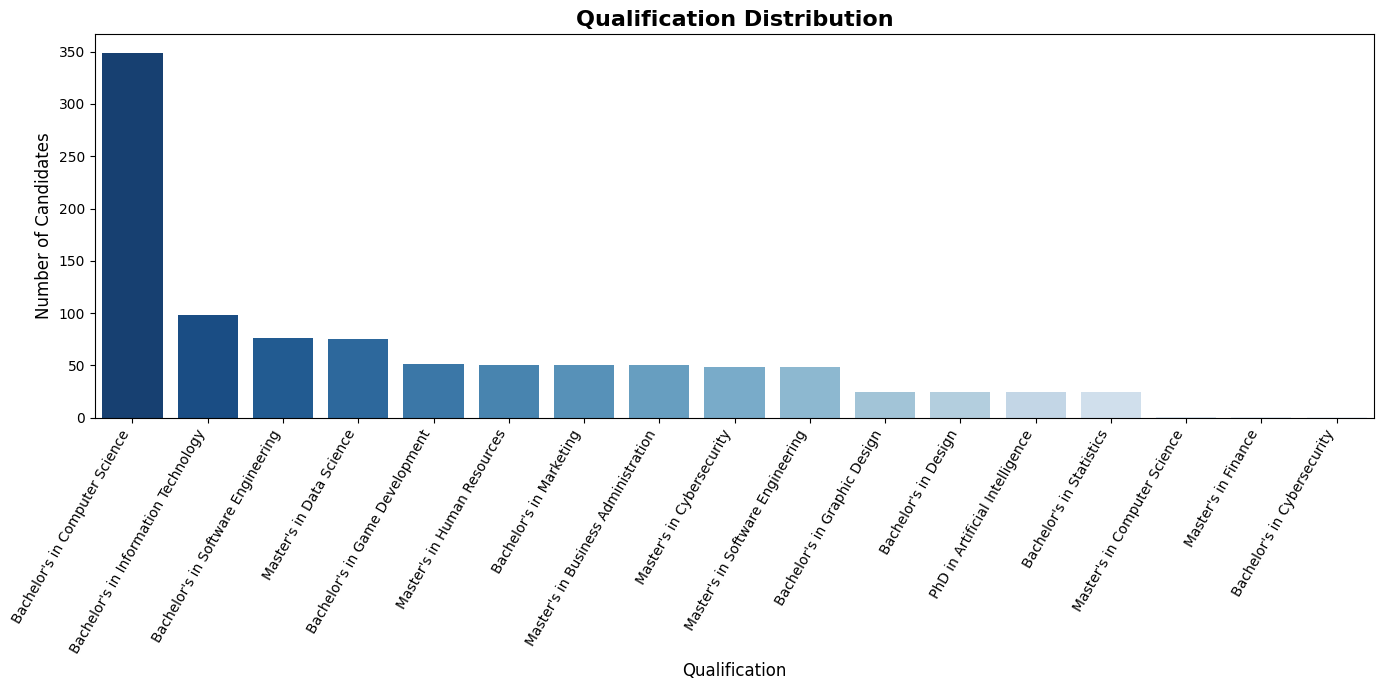

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.countplot(
    data=candidate_df,
    x='qualification',
    order=candidate_df['qualification'].value_counts().index,
    palette='Blues_r'
)

plt.title("Qualification Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Qualification", fontsize=12)
plt.ylabel("Number of Candidates", fontsize=12)

# Rotate and align labels
plt.xticks(rotation=60, ha='right', fontsize=10)

# Adjust layout so labels are not cut off
plt.tight_layout()

plt.show()

**Key Insights:**
- Bachelor's in Computer Science dominates the dataset.
- Information Technology and Software Engineering are the second most common qualifications.
- Advanced degrees (Master's and PhD) are less frequent.
- Several specialized qualifications have very small sample sizes, indicating an imbalanced distribution.


**2.2 Experience Level Distribution**

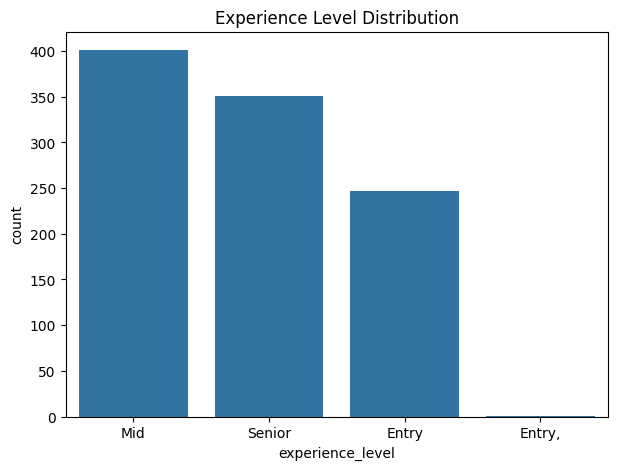

In [55]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=candidate_df,
    x='experience_level',
    order=candidate_df['experience_level'].value_counts().index
)

plt.title("Experience Level Distribution")
plt.show()

#### Key Insights
- **Mid-level candidates** have the highest representation, indicating that the dataset is primarily composed of professionals with moderate industry experience.
- **Senior-level candidates** are also well represented, suggesting a substantial pool of experienced professionals.
- **Entry-level candidates** are comparatively fewer, indicating fewer fresh graduates or early-career applicants.
- There appears to be an additional category labeled **"Entry,"**, which likely results from inconsistent data entry (e.g., an extra comma or whitespace). This should be cleaned by merging it with the **"Entry"** category before further analysis.

#**3. Class Distribution**

**3.1 Top Candidate Job roles**

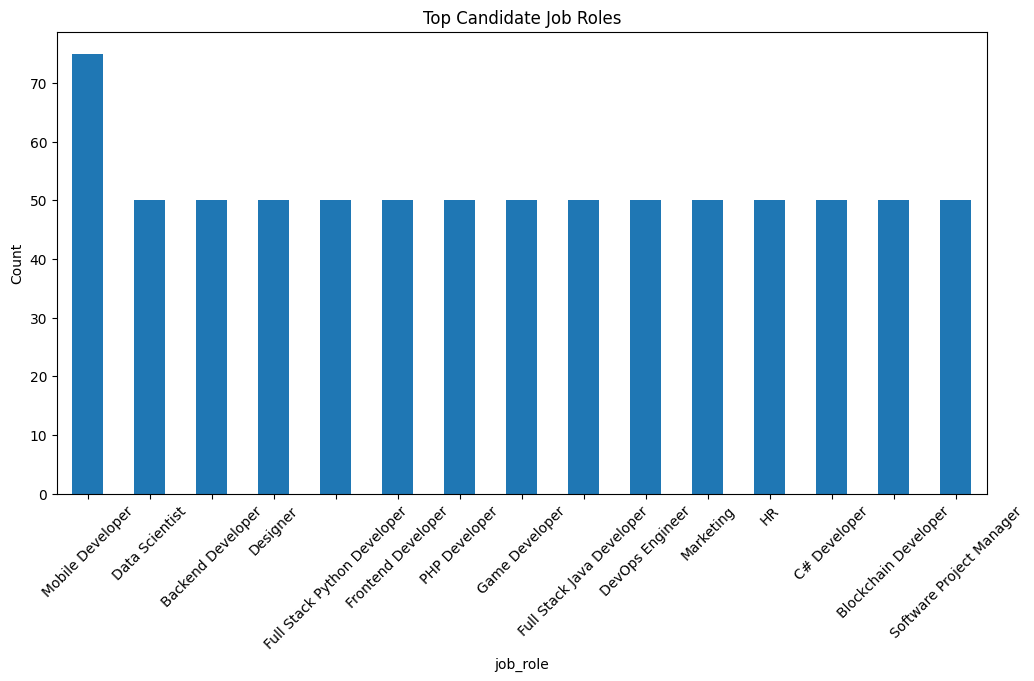

In [56]:
plt.figure(figsize=(12,6))

candidate_df['job_role'].value_counts().head(15).plot(kind='bar')

plt.title("Top Candidate Job Roles")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Insights
- **Mobile Developer** has the highest number of candidates, making it the dominant job role in the dataset.
- Roles such as **Data Scientist**, **Backend Developer**, **Designer**, **Full Stack Python Developer**, **Frontend Developer**, **PHP Developer**, **Game Developer**, **Full Stack Java Developer**, **DevOps Engineer**, **Marketing**, **HR**, **C# Developer**, **Blockchain Developer**, and **Software Project Manager** have similar frequencies.
- The relatively uniform distribution across most job roles suggests that the dataset was designed to include a diverse range of professions with balanced representation.
- The slight dominance of Mobile Developers may indicate higher demand or greater availability of candidates in mobile application development.

#**4. Missing Value Analysis**

In [57]:
candidate_df.isna().sum()

,0
candidate_id,0
skills,0
qualification,0
experience_level,0
job_role,0


No missing values in the dataset

#**5. Duplicate Analysis**

In [58]:
duplicates = candidate_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


No duplicates in the datasets

# **EDA For Job Postings**

#**1. Dataset Summary Statistics**

In [59]:
# Dataset shape
print("Shape:", job_df.shape)

Shape: (123849, 32)


**Drop the unnecessary columns for the Job datasets**

In [60]:
drop_cols = [
    "company_id", "job_posting_url", "application_url", "posting_domain",
    "zip_code", "fips", "closed_time", "original_listed_time",
    "remote_allowed", "views", "applies", "expiry", "sponsored",
    "currency", "pay_period", "compensation_type"
]

job_df = job_df.drop(columns=drop_cols)

In [61]:
# Data types and non-null values
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   job_id                      123849 non-null  int64         
 1   company_name                122130 non-null  object        
 2   title                       123849 non-null  object        
 3   description                 123842 non-null  object        
 4   max_salary                  29793 non-null   float64       
 5   location                    123849 non-null  object        
 6   med_salary                  6280 non-null    float64       
 7   min_salary                  29793 non-null   float64       
 8   formatted_work_type         123849 non-null  object        
 9   application_type            123849 non-null  object        
 10  formatted_experience_level  94440 non-null   object        
 11  skills_desc                 2439 non-nu

In [62]:
# Summary statistics
job_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
job_id,123849.0,NaN,NaN,NaN,3896402138.074615,921716.0,3894586595.0,3901998406.0,3904707077.0,3906267224.0,84043545.161881
company_name,122130,24428,Liberty Healthcare and Rehabilitation Services,1108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,123849,72521,Sales Manager,673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,123842,107827,Position Summary: Our Sales Manager has managi...,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_salary,29793.0,NaN,NaN,NaN,91939.423461,1.0,48.28,80000.0,140000.0,120000000.0,701110.138622
location,123849,8526,United States,8125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
med_salary,6280.0,NaN,NaN,NaN,22015.619876,0.0,18.94,25.5,2510.5,750000.0,52255.873846
min_salary,29793.0,NaN,NaN,NaN,64910.847434,1.0,37.0,60000.0,100000.0,85000000.0,495973.793504
formatted_work_type,123849,7,Full-time,98814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_type,123849,4,OffsiteApply,84607,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
job_df.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'location', 'med_salary', 'min_salary', 'formatted_work_type',
       'application_type', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'work_type', 'normalized_salary', 'listed_datetime'],
      dtype='object')

## Dataset Overview

| Property | Value |
|----------|-------|
| **Total Features** | 14 |
| **Total Sample** | 123849 |
| **Numerical Features** | job_id, listed_time, normalized_salary |
| **Categorical Features** | company_name, pay_period, location, formatted_work_type, application_type, formatted_experience_level, work_type, compensation_type |
| **Text Features** | title, description, skills_desc |
| **Primary Identifier** | job_id |


#**2. Feature Distributions**

**2.1 Top 15 Job titles**

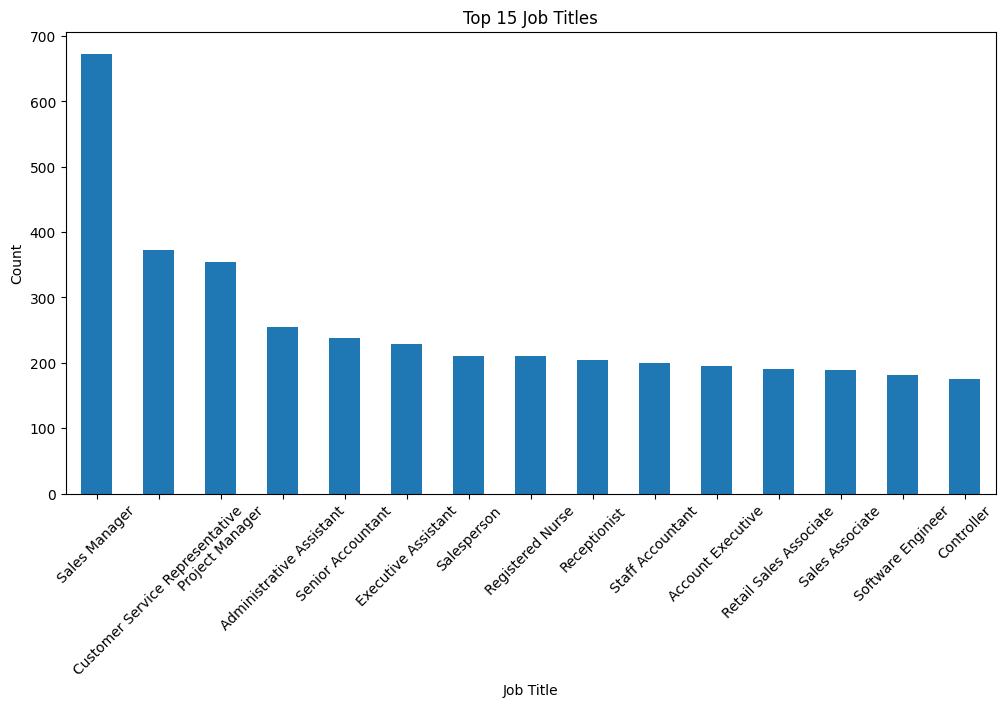

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

job_df['title'].value_counts().head(15).plot(kind='bar')

plt.title("Top 15 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### **Insights**

- The distribution of job titles is **highly imbalanced**, with **Sales Manager** being the most frequently advertised role, having approximately **670 job postings**. This indicates a significantly higher demand compared to other positions.

- Technical positions such as **Software Engineer** appear among the top 15 job titles but with fewer postings than sales and administrative roles. This suggests that while software engineering opportunities are present, the dataset contains a broader mix of industries rather than being exclusively focused on IT jobs.

- The noticeable difference in posting frequencies between the top-ranked job title and the remaining roles highlights a **class imbalance** in the dataset. This imbalance should be considered during model development, as prediction models may become biased toward more frequently occurring job titles if appropriate balancing techniques are not applied.

**2.2 Experience Level Distribution**

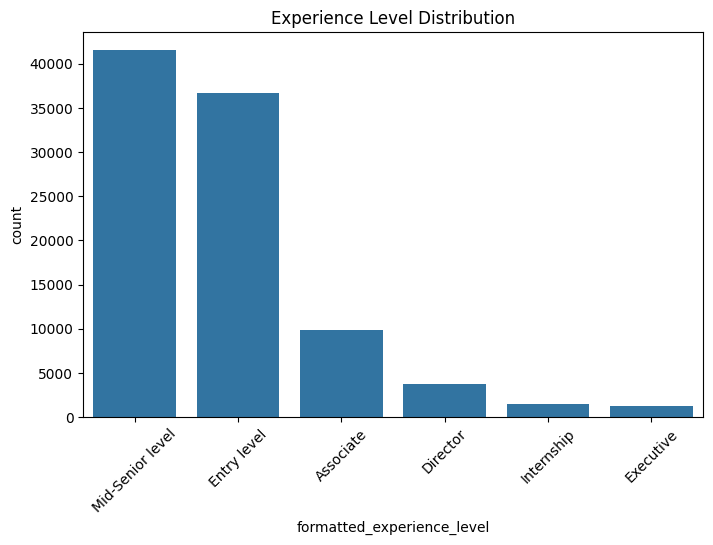

In [65]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=job_df,
    x='formatted_experience_level',
    order=job_df['formatted_experience_level'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Experience Level Distribution")

plt.show()

### **Insights**

- The majority of job postings are targeted toward **Mid-Senior Level** and **Entry Level** professionals, indicating that employers primarily seek candidates with either foundational experience or established industry expertise.

- **Associate** and **Director** positions are available in moderate numbers, while **Internship** and **Executive** roles account for only a small proportion of the postings, reflecting lower hiring demand for these experience levels.

- The distribution is **imbalanced**, with Mid-Senior and Entry Level positions dominating the dataset. This imbalance should be considered during model development, as recommendation or classification models may otherwise favor the more frequently represented experience levels.

**2.3 Employment type Distribution**

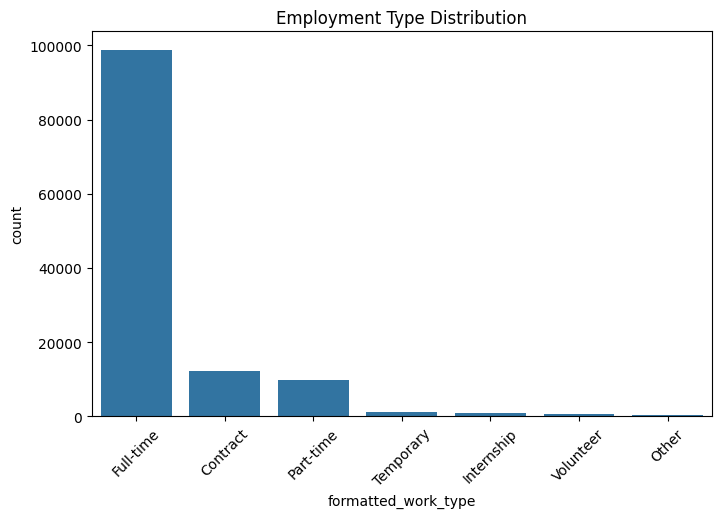

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=job_df,
    x='formatted_work_type',
    order=job_df['formatted_work_type'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Employment Type Distribution")

plt.show()

### **Insights**

- **Full-time positions** dominate the dataset by a large margin, accounting for the vast majority of job postings. This indicates that employers primarily seek candidates for permanent, long-term employment.

- **Contract** and **Part-time** roles are the next most common employment types, but they represent a much smaller share compared to full-time positions. Temporary, internship, volunteer, and other employment types occur only infrequently.

- The distribution is **highly imbalanced**, with full-time jobs significantly outnumbering all other employment types. This suggests that recommendation models trained on this dataset may naturally prioritize full-time opportunities unless measures are taken to account for the underrepresented employment categories.

#**3. Class Distribution**




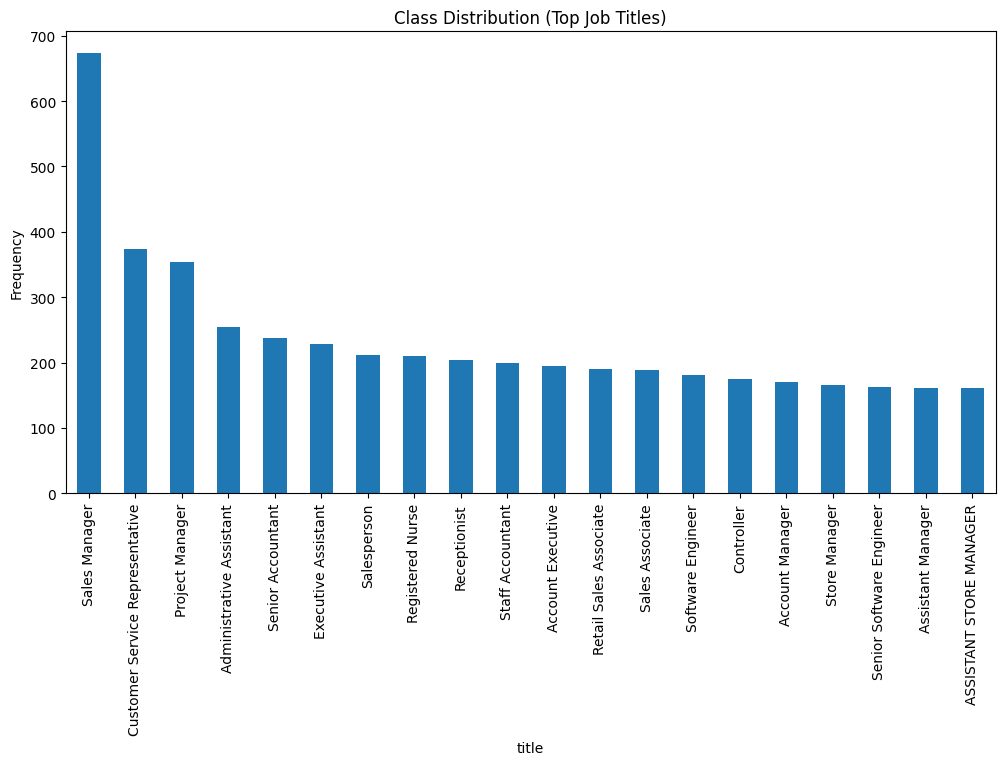

In [67]:
plt.figure(figsize=(12,6))

job_df['title'].value_counts().head(20).plot(kind='bar')

plt.title("Class Distribution (Top Job Titles)")
plt.ylabel("Frequency")

plt.show()

### **Insights**

- The class distribution is **highly skewed**, with **Sales Manager** being the most frequent job title, followed by **Customer Service Representative** and **Project Manager**. This indicates that these roles have the highest hiring demand in the dataset.

- Administrative, finance, retail, and software-related positions are also well represented, demonstrating that the dataset covers a diverse range of industries and occupations rather than focusing on a single domain.

- The noticeable imbalance in job title frequencies suggests that machine learning models trained on this dataset may become biased toward the most common job classes. Therefore, techniques such as class weighting, oversampling, or balanced evaluation metrics should be considered during model development.

#**4. Missing Value Analysis**

In [68]:
missing = job_df.isnull().sum().sort_values(ascending=False)

print(missing)

skills_desc                   121410
med_salary                    117569
min_salary                     94056
max_salary                     94056
normalized_salary              87776
formatted_experience_level     29409
company_name                    1719
description                        7
location                           0
title                              0
job_id                             0
application_type                   0
formatted_work_type                0
listed_time                        0
work_type                          0
listed_datetime                    0
dtype: int64


## The Columns that contains missing datasets are
1.skills_desc                   
2.pay_period                    
3.normalized_salary              
4.compensation_type             
5.formatted_experience_level     
6.company_name                   
7.description

# **5. Duplicate Analysis**

In [69]:
duplicates = job_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


No duplicates in this datasets

#**6. Outlier Analysis**

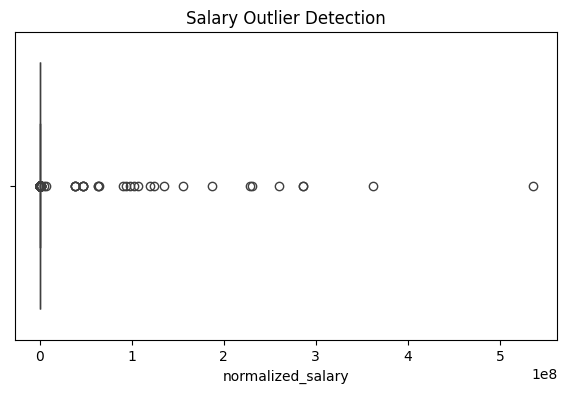

In [70]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=job_df['normalized_salary']
)

plt.title("Salary Outlier Detection")

plt.show()

### **Insights**

- The boxplot shows that **most salary values are concentrated within a relatively low range**, while several observations lie far above the upper whisker. These points represent high-paying positions that are considered statistical outliers.

- The salary distribution is **positively (right) skewed**, indicating that although most job postings offer moderate salaries, a small number of positions provide exceptionally high compensation.

- These outliers are likely to correspond to **senior, executive, or highly specialized roles**. Instead of removing them immediately, they should be carefully evaluated, as they may represent valid observations that are important for salary prediction and job recommendation models.

# **7. Correlation Analysis**

**7.1 Correlation Analysis of Numerical Features**

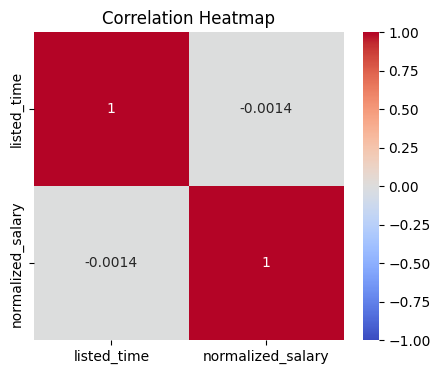

In [71]:
corr = job_df[
    ['listed_time','normalized_salary']
].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")

plt.show()

### **Insights**

- The correlation heatmap shows an almost **zero correlation (-0.0014)** between **listed_time** and **normalized_salary**, indicating that the time a job was listed has virtually no linear relationship with the salary offered.

- The diagonal values of **1.0** represent the perfect correlation of each variable with itself, which is expected in any correlation matrix.

- Since the dataset contains only two numerical features and their correlation is negligible, salary appears to be influenced by other factors such as **job title, experience level, company, location, and employment type**, rather than the job posting date. These categorical features are therefore likely to provide more predictive value during model development.

**7.2 Experience Level vs Employment Type Analysis**

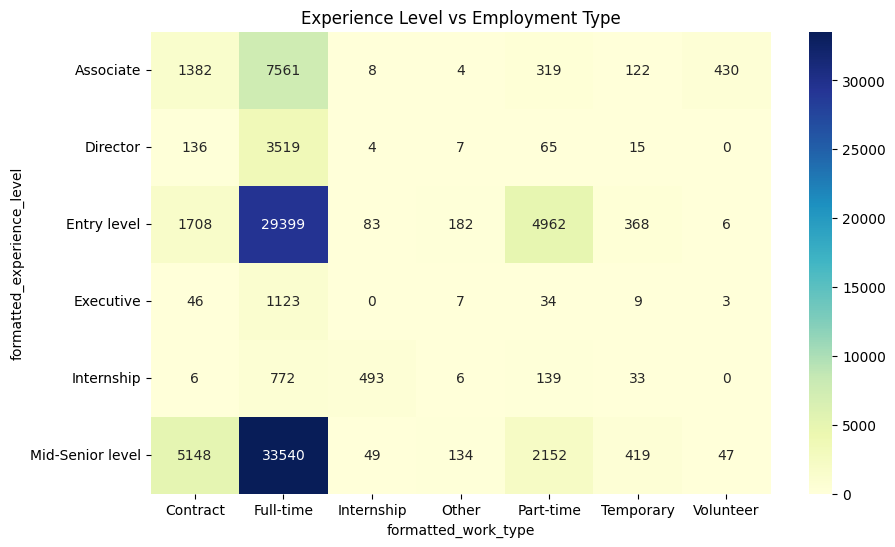

In [72]:
cross = pd.crosstab(
    job_df['formatted_experience_level'],
    job_df['formatted_work_type']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cross,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Experience Level vs Employment Type")

plt.show()

### **Insights**

- **Full-time employment** is the dominant employment type across all experience levels. The highest number of postings is observed for **Mid-Senior Level** (33,540) and **Entry Level** (29,399), indicating that organizations primarily recruit experienced professionals and new graduates for permanent positions.

- **Part-time** and **Contract** opportunities are available across most experience levels but occur in significantly lower numbers compared to full-time roles. Entry-level candidates have the highest number of part-time positions (4,962), while Mid-Senior Level candidates have the highest number of contract positions (5,148).

- **Internship**, **Temporary**, **Volunteer**, and **Other** employment types represent only a small proportion of the dataset. Internship positions are naturally concentrated within the **Internship** and **Entry Level** categories, reflecting hiring practices for students and early-career professionals.

### **Dataset Comparison & Column Manipulation Plan**

**Goal:** Identify how the Candidate dataset and Job Postings dataset differ, and which columns must be manipulated to enable ranking jobs against candidates.

---

#### **1. Category-Level Comparison of Matching Columns**

| Aspect | Candidate side | Job side | Mismatch |
|---|---|---|---|
| **Experience** | `experience_level` — 4 unique values (Entry, Junior, Mid, Senior); top = "Mid" (401/1000) | `formatted_experience_level` — 6 unique values (Internship, Entry level, Associate, Mid-Senior level, Director, Executive); top = "Mid-Senior level"; ~29,000 missing rows | Different label sets and granularity; candidate side also has a stray `"Entry, "` typo |
| **Role / Title** | `job_role` — 22 unique values, clean controlled vocabulary (e.g. "Mobile Developer", top freq 75) | `title` — 72,521 unique values, free text (e.g. "Sales Manager", "Senior Sales Manager – East") | Candidate side is categorical; job side is uncontrolled free text — direct equality matching will fail |
| **Skills** | `skills` — 98 unique combinations, comma-separated (e.g. "PHP, Laravel, MySQL, JavaScript", top freq 25) | `skills_desc` — only 2,439 non-null rows out of 123,849 (98% missing); when present, 2,212 unique free-text sentences | Candidate side is compact and structured; job side is almost entirely empty and unstructured when present |

**Takeaway:** No shared key or common category system exists between the two datasets. Each "equivalent" column pair differs in cardinality, format, or missingness, so ranking cannot be built with a simple join — each pair needs its own manipulation.

---

#### **2. Proposed Manipulation (3 columns per side)**

**A. Experience Level → collapse to one shared scale**
- Clean candidate typo: strip whitespace/trailing commas so `"Entry, "` → `"Entry"`.
- Map job's 6 categories down to candidate's 4-bucket scale:
  - `Internship` / `Entry level` → `Entry`
  - `Associate` → `Junior`
  - `Mid-Senior level` → `Mid`
  - `Director` / `Executive` → `Senior`
- Fill missing job values with `"Unknown"` instead of dropping (avoids losing ~23% of postings).

**B. Role / Title → map job's free text into candidate's controlled vocabulary**
- Use fuzzy or embedding similarity (e.g. RapidFuzz `token_sort_ratio`, or sentence embeddings + cosine similarity) to score each `title` against the 22 `job_role` labels.
- Store the best match as a new `matched_role` column plus its similarity score.

**C. Skills → build one comparable text field**
- Since `skills_desc` is 98% empty, concatenate `title + skills_desc + description` into a single `job_text` field per posting.
- Keep candidate `skills` as-is.
- Vectorize both with BM25 and compute cosine similarity between each candidate's `skills` and each job's `job_text`.

---


| Aspect | Candidate Side | Job Side | Mismatch |
|--------|----------------|----------|----------|
| **Experience** | `experience_level` — 4 unique values (`Entry`, `Junior`, `Mid`, `Senior`); top = **"Mid"** (401/1000) | `formatted_experience_level` — 6 unique values (`Internship`, `Entry level`, `Associate`, `Mid-Senior level`, `Director`, `Executive`); top = **"Mid-Senior level"**; ~29,000 missing rows | Different label sets and granularity; candidate side also has a stray `"Entry, "` typo. |
| **Role / Title** | `job_role` — 22 unique values, clean controlled vocabulary (e.g., `"Mobile Developer"`; top frequency = 75) | `title` — 72,521 unique values, free text (e.g., `"Sales Manager"`, `"Senior Sales Manager – East"`) | Candidate side is categorical; job side is uncontrolled free text, so direct equality matching will fail. |
| **Skills** | `skills` — 98 unique combinations, comma-separated (e.g., `"PHP, Laravel, MySQL, JavaScript"`; top frequency = 25) | `skills_desc` — only 2,439 non-null rows out of 123,849 (≈98% missing); when present, 2,212 unique free-text sentences | Candidate side is compact and structured; job side is almost entirely empty and unstructured when present. |

# **4. Feature Relationships**

### **4.1 Skill Frequency by Occupation**

Skills alone (frequency across the whole dataset) were reported in the original EDA, but not **broken down by occupation** — which is the relationship the matching model actually needs (which skills are diagnostic of which role).

In [74]:
# Explode the comma-separated skills field and tie each skill back to its job_role
skills_by_role = candidate_df.assign(skill=candidate_df['skills'].str.split(','))
skills_by_role = skills_by_role.explode('skill')
skills_by_role['skill'] = skills_by_role['skill'].str.strip()

# Top 5 skills per role
top_skills_per_role = (
    skills_by_role.groupby('job_role')['skill']
    .apply(lambda s: s.value_counts().head(5))
)
print(top_skills_per_role)

job_role                       
AIML           Python              25
               Deep Learning       25
               NLP                 25
               TensorFlow          24
               Machine Learning     1
                                   ..
Web Developer  JavaScript          49
               HTML                25
               CSS                 25
               Node.js             25
               MongoDB             25
Name: skill, Length: 108, dtype: int64


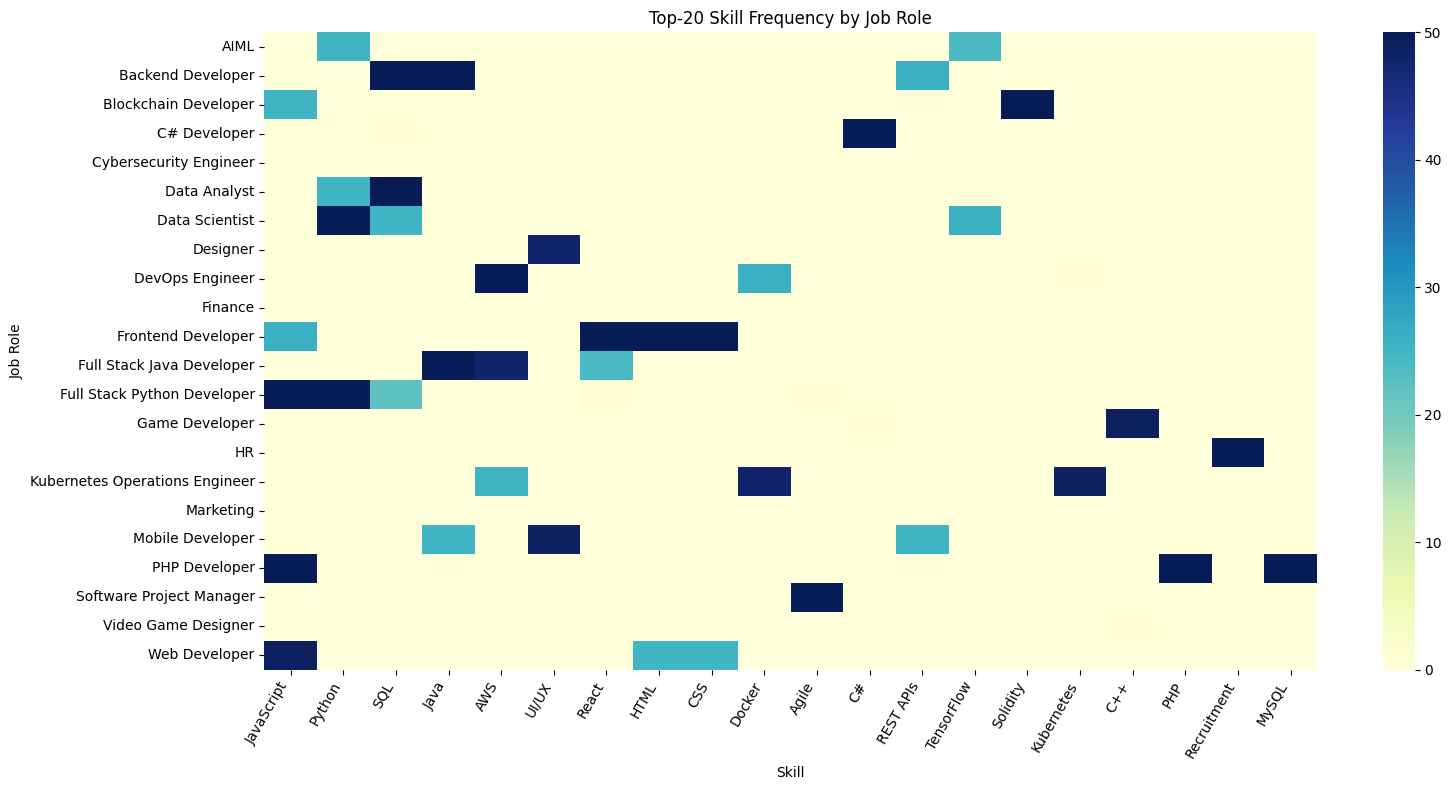

In [75]:
# Heatmap: frequency of the overall top 20 skills, split by job_role
top20_skills = skills_by_role['skill'].value_counts().head(20).index
pivot = pd.crosstab(skills_by_role['job_role'], skills_by_role['skill'])[top20_skills]

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title("Top-20 Skill Frequency by Job Role")
plt.xlabel("Skill")
plt.ylabel("Job Role")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### **Key Insights (Markdown)**

* **Programming languages** such as **Python, Java, JavaScript, SQL, and C#** are the most frequently required skills across multiple technical job roles.
* **Frontend Developer** roles are strongly associated with **React, HTML, CSS, and JavaScript**, reflecting the core frontend technology stack.
* **Backend** and **Full Stack Java Developer** roles primarily require **Java, AWS, and SQL**, highlighting backend development and cloud expertise.
* **Full Stack Python Developer**, **Data Scientist**, and **AIML** roles show high demand for **Python**, with **TensorFlow** also prominent in AI/ML positions.
* **DevOps Engineer** and **Kubernetes Operations Engineer** roles emphasize **Docker, Kubernetes, and AWS**, indicating the importance of cloud and containerization technologies.
* **Data Analyst** roles are highly associated with **SQL** and **Python**, emphasizing data querying and analytical programming skills.
* **Designer** and **Mobile Developer** roles require specialized skills such as **UI/UX**, while **Game Developer** emphasizes **C++**.
* **HR** and **Marketing** roles feature more domain-specific skills (e.g., **Recruitment**), showing that non-technical positions require distinct competencies.
* Overall, the heatmap demonstrates that while some **core programming skills are shared across multiple software roles**, each job role has a **unique combination of specialized skills** that differentiates it from others.



### **4.2 Education vs. Role**

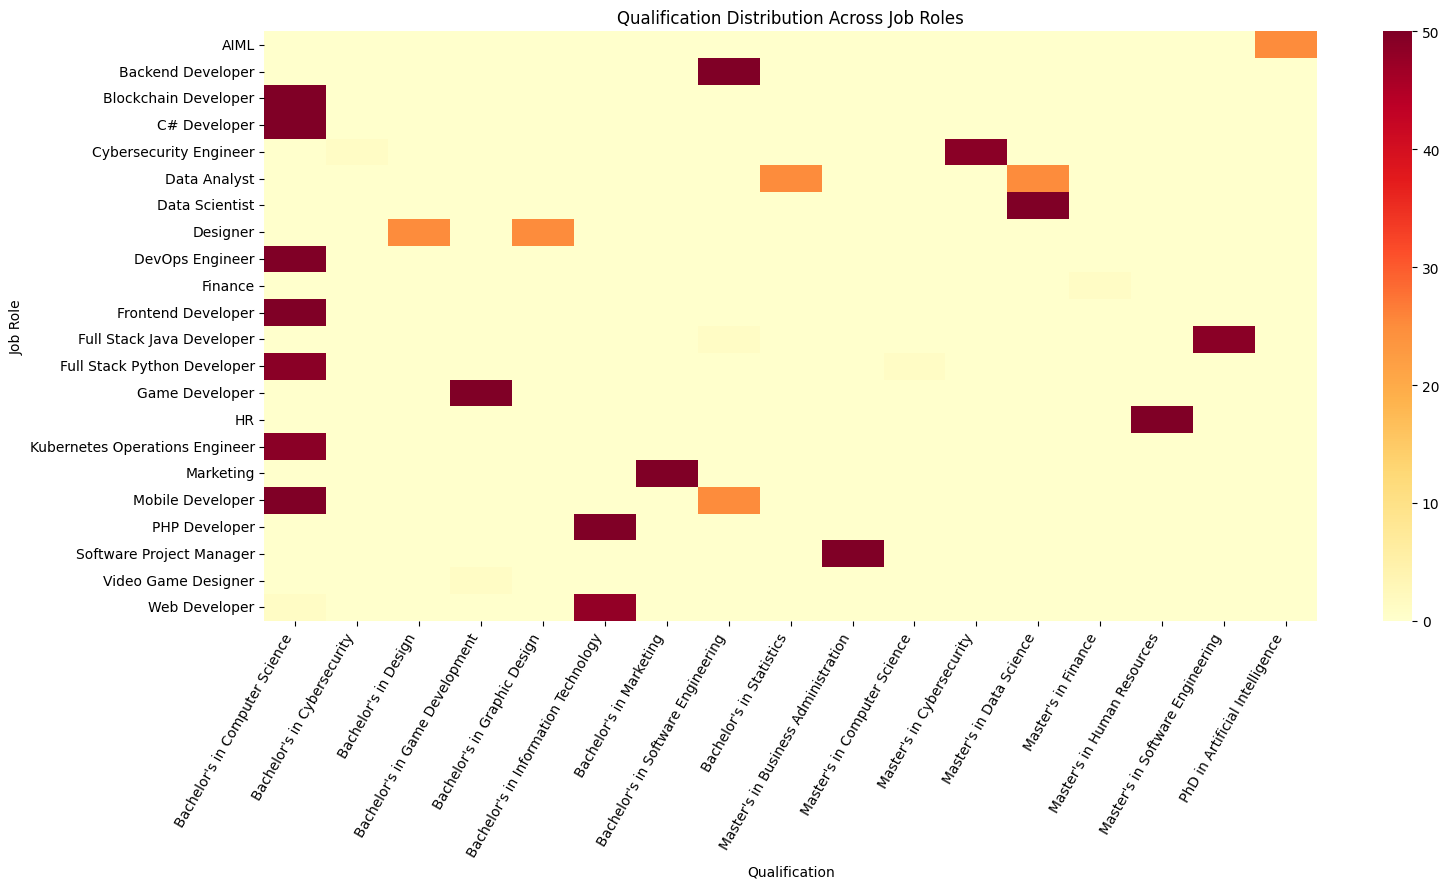

In [76]:
edu_role = pd.crosstab(candidate_df['job_role'], candidate_df['qualification'])

plt.figure(figsize=(16, 9))
sns.heatmap(edu_role, cmap='YlOrRd', annot=False)
plt.title("Qualification Distribution Across Job Roles")
plt.xlabel("Qualification")
plt.ylabel("Job Role")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### **Key Insights (Markdown)**

* **Bachelor's in Computer Science** is the most common qualification, supporting a wide range of software development and engineering roles.
* **Specialized master's degrees** (Data Science, Cybersecurity, Human Resources, and MBA) are strongly aligned with their respective job roles.
* **Creative roles** such as **Designer** and **Game Developer** are primarily associated with specialized bachelor's degrees in **Design**, **Graphic Design**, and **Game Development**.
* **Backend**, **Full Stack Java**, and **Mobile Developer** roles show a preference for **Software Engineering** qualifications.
* **AIML** roles are notably associated with a **PhD in Artificial Intelligence**, indicating demand for advanced AI expertise.
* The heatmap shows a **clear one-to-one relationship between qualifications and job roles**, highlighting the importance of domain-specific education for different career paths.


### **4.3 Experience vs. Salary**

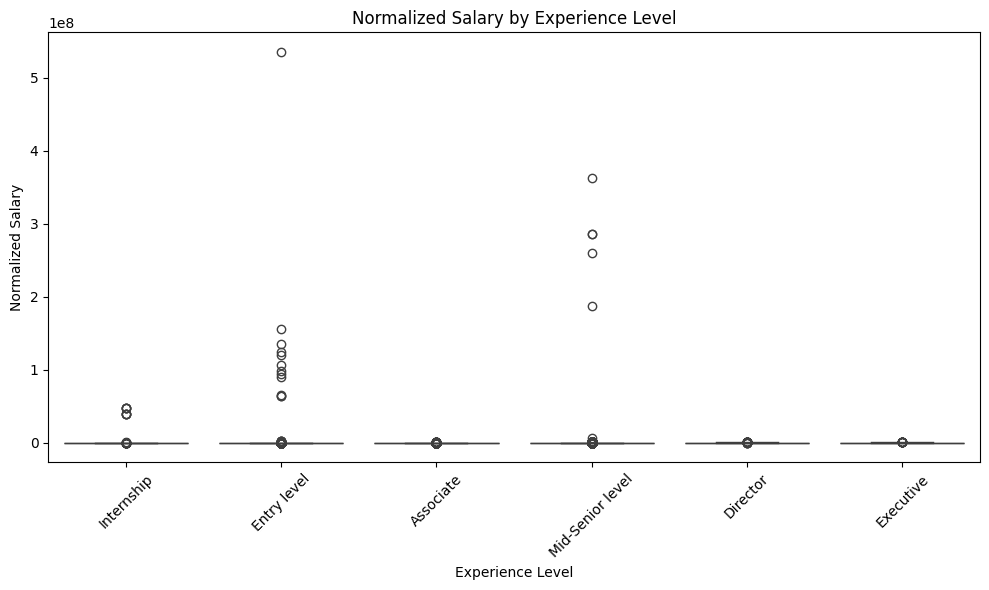

In [77]:
order = (job_df.groupby('formatted_experience_level')['normalized_salary']
          .median().sort_values().index)

plt.figure(figsize=(10, 6))
sns.boxplot(data=job_df, x='formatted_experience_level', y='normalized_salary', order=order)
plt.title("Normalized Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Normalized Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Key Insights (Markdown)**

* **Entry-level** professionals exhibit the **highest salary variation**, with several extreme outliers indicating a wide pay range.
* **Mid-Senior level** roles also show significant salary dispersion, reflecting higher earning potential with experience.
* **Internship** salaries are generally the lowest, with only a few high-value outliers.
* **Associate**, **Director**, and **Executive** levels display relatively **more consistent salary distributions** with fewer extreme values.
* The presence of **large salary outliers** suggests that factors such as company, location, or specialized skills can substantially influence compensation beyond experience level alone.
* Overall, **salary tends to increase with experience**, but variability is greatest at **Entry-level** and **Mid-Senior level** positions.


### **4.4 Skills Shared Across Occupations**

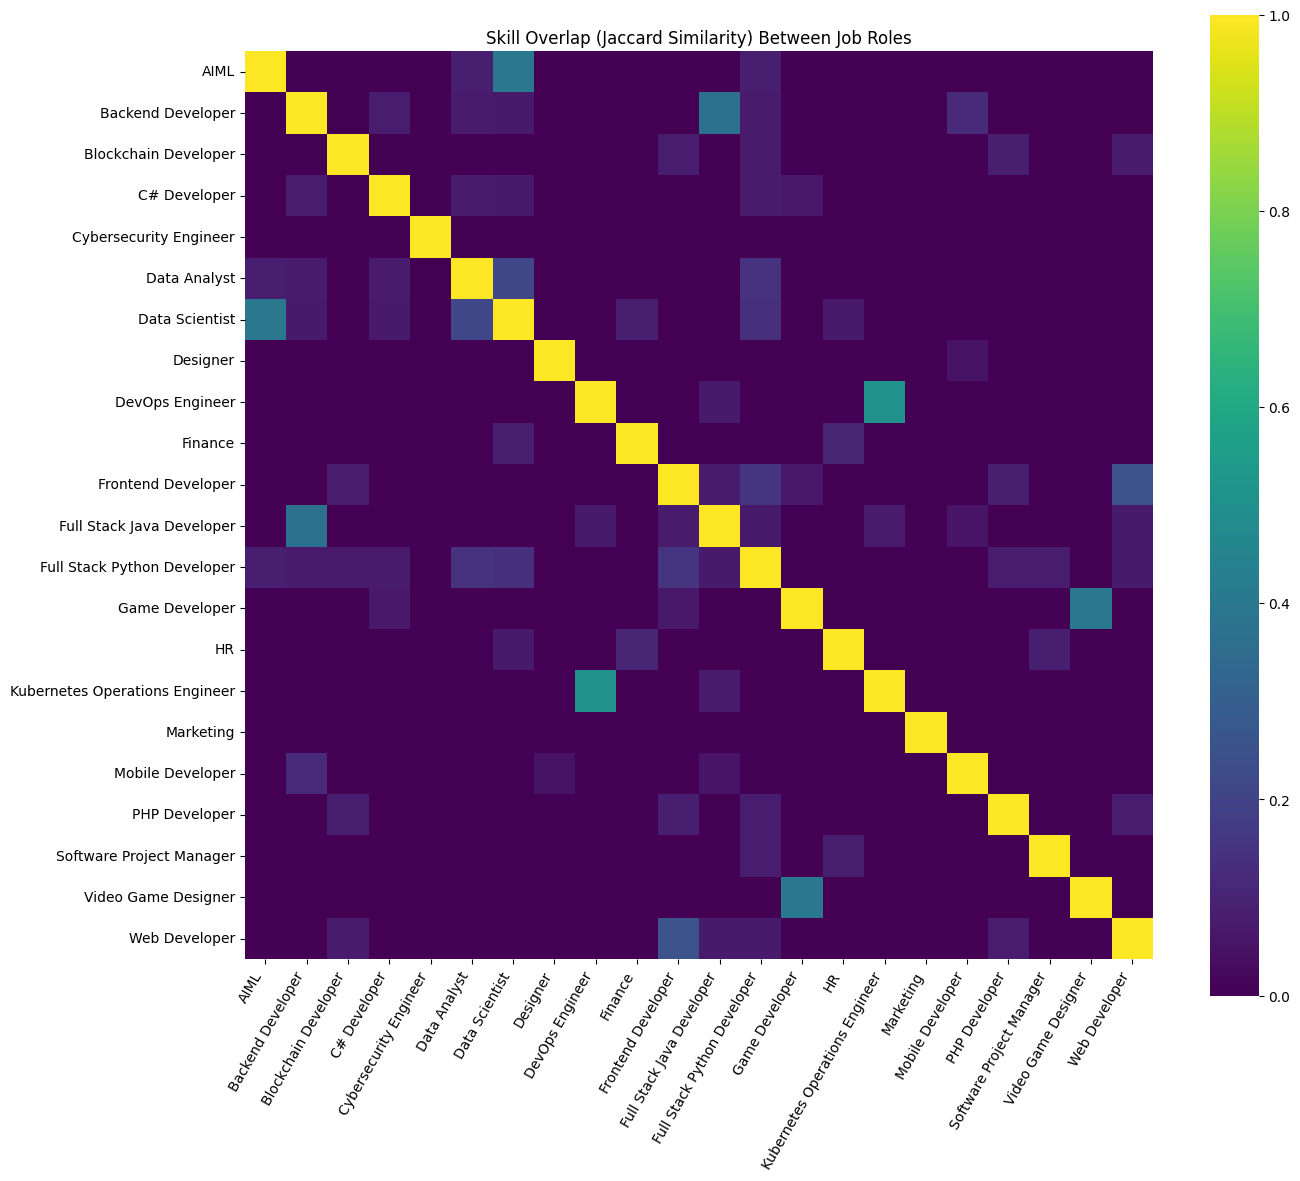

In [78]:
# Jaccard similarity of skill sets between every pair of candidate job_roles
role_skill_sets = skills_by_role.groupby('job_role')['skill'].apply(set)
roles = role_skill_sets.index.tolist()

jaccard = pd.DataFrame(index=roles, columns=roles, dtype=float)
for r1 in roles:
    for r2 in roles:
        s1, s2 = role_skill_sets[r1], role_skill_sets[r2]
        union = s1 | s2
        jaccard.loc[r1, r2] = len(s1 & s2) / len(union) if union else 0.0

plt.figure(figsize=(14, 12))
sns.heatmap(jaccard.astype(float), cmap='viridis', square=True)
plt.title("Skill Overlap (Jaccard Similarity) Between Job Roles")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### **Key Insights (Markdown)**

* Most job roles exhibit **low skill overlap**, indicating that each role requires a distinct and specialized skill set.
* **Backend Developer**, **Full Stack Java Developer**, and **DevOps Engineer** show relatively **higher skill similarity**, reflecting shared software development and infrastructure skills.
* **Data Analyst**, **Data Scientist**, and **AIML** roles have noticeable overlap due to common skills in **data analysis, machine learning, and programming**.
* **Frontend Developer** and **Web Developer** share moderate similarity, highlighting their common focus on web technologies.
* **Game Developer** and **Video Game Designer** demonstrate a relatively high skill overlap because of their shared involvement in game development workflows.
* The strong diagonal (similarity = **1.0**) confirms that each job role is perfectly similar to itself, while the generally darker off-diagonal values indicate **limited cross-role skill overlap**.
